## 处理原始数据

In [1]:
import json
import os

import xxhash
import tqdm
import logging
import networkx as nx
from tqdm import tqdm
import time
import datetime

#### 全局变量定义

In [ ]:
VERBOSE = False # 是否打印详细信息
NO_ENCODE = False # 是否不编码（哈希映射）
STATS = False # 是否统计时间戳（基于最小时间的偏差）
JIFFIES = False # 是否提取时间戳
BIDIRECTION = False # 是否双向图

# 样本数量
NORMAL_NUMS = 100 # <=125
ATTACK_NUMS = 20 # <=25

# 结点类型
valid_node_type = ['file', 'process_memory', 'task', 'mmaped_file', 'path', 'socket', 'address', 'link']

#### 解析结点

In [3]:
def parse_nodes(json_string, node_map):
    """解析CamFlow JSON字符串中的节点("activity"或"entity")。
    解析结果存入@node_map字典，该字典将CamFlow分配的节点UID映射到表示节点类型的哈希值(str类型)。"""
    json_object = None
    try:
        # use "ignore" if non-decodeable exists in the @json_string
        json_object = json.loads(json_string)
    except Exception as e:
        print("Exception ({}) occurred when parsing a node in JSON:".format(e))
        print(json_string)
        exit(1)
    if "activity" in json_object:
        activity = json_object["activity"]
        for uid in activity:
            if not uid in node_map:  # only parse unseen nodes
                if "prov:type" not in activity[uid]:
                    # a node must have a type.
                    # record this issue if logging is turned on
                    if VERBOSE:
                        logging.debug("skipping a problematic activity node with no 'prov:type': {}".format(uid))
                else:
                    node_map[uid] = activity[uid]["prov:type"]

    if "entity" in json_object:
        entity = json_object["entity"]
        for uid in entity:
            if not uid in node_map:
                if "prov:type" not in entity[uid]:
                    if VERBOSE:
                        logging.debug("skipping a problematic entity node with no 'prov:type': {}".format(uid))
                else:
                    node_map[uid] = entity[uid]["prov:type"]

def parse_all_nodes(filename, node_map):
    """解析CamFlow数据中的所有节点。@filename是数据文件路径，@node_map存储节点到其哈希属性的映射"""
    description = '\x1b[6;30;42m[STATUS]\x1b[0m Parsing nodes in CamFlow data from {}'.format(filename)
    pb = tqdm(desc=description, mininterval=1.0, unit=" recs")
    with open(filename, 'r') as f:
        # each line in CamFlow data could contain multiple
        # provenance nodes, we call @parse_nodes routine.
        for line in f:
            pb.update()  # for progress tracking
            parse_nodes(line, node_map)
    f.close()
    pb.close()

#### 解析边

In [ ]:
def hashgen(l):
    """从列表中生成单个哈希值。@l是一个字符串列表，可以是节点/边的属性。
    此函数返回一个哈希后的整数值。"""
    hasher = xxhash.xxh64()
    for e in l:
        hasher.update(e)
    return hasher.intdigest()

# inputfile：CamFlow数据文件
# outputfile：输出log文件
def parse_all_edges(inputfile, outputfile, node_map, noencode):
    """从CamFlow数据文件@inputfile中解析所有边(包括时间戳)到@outputfile。在调用此函数前，应先调用parse_all_nodes
    来填充@node_map中所有CamFlow文件的节点。如果设置了@noencode，我们不会将CamFlow生成的原始UUID哈希为整数。
    此函数返回从CamFlow数据集中解析出的有效边的总数。

    输出的边列表每行格式如下(如果未设置-s参数):
        <源节点ID> \t <目标节点ID> \t <源类型>:<目标类型>:<边类型>:<边逻辑时间戳>
    如果设置了-s参数，每行格式如下:
        <源节点ID> \t <目标节点ID> \t <源类型>:<目标类型>:<边类型>:<边逻辑时间戳>:<时间戳统计信息>"""
    total_edges = 0
    smallest_timestamp = None
    # scan through the entire file to find the smallest timestamp from all the edges.
    # this step is only needed if we need to add some statistical information.
    if STATS:
        description = '\x1b[6;30;42m[STATUS]\x1b[0m Scanning edges in CamFlow data from {}'.format(inputfile)
        pb = tqdm(desc=description, mininterval=1.0, unit=" recs")
        with open(inputfile, 'r') as f:
            for line in f:
                pb.update()
                json_object = json.loads(line)

                if "used" in json_object:
                    used = json_object["used"]
                    for uid in used:
                        if "prov:type" not in used[uid]:
                            continue
                        if "cf:date" not in used[uid]:
                            continue
                        if "prov:entity" not in used[uid]:
                            continue
                        if "prov:activity" not in used[uid]:
                            continue
                        srcUUID = used[uid]["prov:entity"]
                        dstUUID = used[uid]["prov:activity"]
                        if srcUUID not in node_map:
                            continue
                        if dstUUID not in node_map:
                            continue
                        timestamp_str = used[uid]["cf:date"]
                        ts = time.mktime(datetime.datetime.strptime(timestamp_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                        if smallest_timestamp == None or ts < smallest_timestamp:
                            smallest_timestamp = ts

                if "wasGeneratedBy" in json_object:
                    wasGeneratedBy = json_object["wasGeneratedBy"]
                    for uid in wasGeneratedBy:
                        if "prov:type" not in wasGeneratedBy[uid]:
                            continue
                        if "cf:date" not in wasGeneratedBy[uid]:
                            continue
                        if "prov:entity" not in wasGeneratedBy[uid]:
                            continue
                        if "prov:activity" not in wasGeneratedBy[uid]:
                            continue
                        srcUUID = wasGeneratedBy[uid]["prov:activity"]
                        dstUUID = wasGeneratedBy[uid]["prov:entity"]
                        if srcUUID not in node_map:
                            continue
                        if dstUUID not in node_map:
                            continue
                        timestamp_str = wasGeneratedBy[uid]["cf:date"]
                        ts = time.mktime(datetime.datetime.strptime(timestamp_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                        if smallest_timestamp == None or ts < smallest_timestamp:
                            smallest_timestamp = ts

                if "wasInformedBy" in json_object:
                    wasInformedBy = json_object["wasInformedBy"]
                    for uid in wasInformedBy:
                        if "prov:type" not in wasInformedBy[uid]:
                            continue
                        if "cf:date" not in wasInformedBy[uid]:
                            continue
                        if "prov:informant" not in wasInformedBy[uid]:
                            continue
                        if "prov:informed" not in wasInformedBy[uid]:
                            continue
                        srcUUID = wasInformedBy[uid]["prov:informant"]
                        dstUUID = wasInformedBy[uid]["prov:informed"]
                        if srcUUID not in node_map:
                            continue
                        if dstUUID not in node_map:
                            continue
                        timestamp_str = wasInformedBy[uid]["cf:date"]
                        ts = time.mktime(datetime.datetime.strptime(timestamp_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                        if smallest_timestamp == None or ts < smallest_timestamp:
                            smallest_timestamp = ts

                if "wasDerivedFrom" in json_object:
                    wasDerivedFrom = json_object["wasDerivedFrom"]
                    for uid in wasDerivedFrom:
                        if "prov:type" not in wasDerivedFrom[uid]:
                            continue
                        if "cf:date" not in wasDerivedFrom[uid]:
                            continue
                        if "prov:usedEntity" not in wasDerivedFrom[uid]:
                            continue
                        if "prov:generatedEntity" not in wasDerivedFrom[uid]:
                            continue
                        srcUUID = wasDerivedFrom[uid]["prov:usedEntity"]
                        dstUUID = wasDerivedFrom[uid]["prov:generatedEntity"]
                        if srcUUID not in node_map:
                            continue
                        if dstUUID not in node_map:
                            continue
                        timestamp_str = wasDerivedFrom[uid]["cf:date"]
                        ts = time.mktime(datetime.datetime.strptime(timestamp_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                        if smallest_timestamp == None or ts < smallest_timestamp:
                            smallest_timestamp = ts

                if "wasAssociatedWith" in json_object:
                    wasAssociatedWith = json_object["wasAssociatedWith"]
                    for uid in wasAssociatedWith:
                        if "prov:type" not in wasAssociatedWith[uid]:
                            continue
                        if "cf:date" not in wasAssociatedWith[uid]:
                            continue
                        if "prov:agent" not in wasAssociatedWith[uid]:
                            continue
                        if "prov:activity" not in wasAssociatedWith[uid]:
                            continue
                        srcUUID = wasAssociatedWith[uid]["prov:agent"]
                        dstUUID = wasAssociatedWith[uid]["prov:activity"]
                        if srcUUID not in node_map:
                            continue
                        if dstUUID not in node_map:
                            continue
                        timestamp_str = wasAssociatedWith[uid]["cf:date"]
                        ts = time.mktime(datetime.datetime.strptime(timestamp_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                        if smallest_timestamp == None or ts < smallest_timestamp:
                            smallest_timestamp = ts
        f.close()
        pb.close()

    # we will go through the CamFlow data (again) and output edgelist to a file
    output = open(outputfile, "w+")
    description = '\x1b[6;30;42m[STATUS]\x1b[0m Parsing edges in CamFlow data from {}'.format(inputfile)
    pb = tqdm(desc=description, mininterval=1.0, unit=" recs")
    with open(inputfile, 'r') as f:
        for line in f:
            pb.update()
            json_object = json.loads(line)

            if "used" in json_object:
                used = json_object["used"]
                for uid in used:
                    if "prov:type" not in used[uid]:
                        # an edge must have a type; if not,
                        # we will have to skip the edge. Log
                        # this issue if verbose is set.
                        if VERBOSE:
                            logging.debug("edge (used) record without type: {}".format(uid))
                        continue
                    else:
                        edgetype = "used"
                    # cf:id is used as logical timestamp to order edges
                    if "cf:id" not in used[uid]:
                        # an edge must have a logical timestamp;
                        # if not we will have to skip the edge.
                        # Log this issue if verbose is set.
                        if VERBOSE:
                            logging.debug("edge (used) record without logical timestamp: {}".format(uid))
                        continue
                    else:
                        timestamp = used[uid]["cf:id"]
                    if "prov:entity" not in used[uid]:
                        # an edge's source node must exist;
                        # if not, we will have to skip the
                        # edge. Log this issue if verbose is set.
                        if VERBOSE:
                            logging.debug(
                                "edge (used/{}) record without source UUID: {}".format(used[uid]["prov:type"], uid))
                        continue
                    if "prov:activity" not in used[uid]:
                        # an edge's destination node must exist;
                        # if not, we will have to skip the edge.
                        # Log this issue if verbose is set.
                        if VERBOSE:
                            logging.debug(
                                "edge (used/{}) record without destination UUID: {}".format(used[uid]["prov:type"],
                                                                                            uid))
                        continue
                    srcUUID = used[uid]["prov:entity"]
                    dstUUID = used[uid]["prov:activity"]
                    # both source and destination node must
                    # exist in @node_map; if not, we will
                    # have to skip the edge. Log this issue
                    # if verbose is set.
                    if srcUUID not in node_map:
                        if VERBOSE:
                            logging.debug(
                                "edge (used/{}) record with an unseen srcUUID: {}".format(used[uid]["prov:type"], uid))
                        continue
                    else:
                        srcVal = node_map[srcUUID]
                    if dstUUID not in node_map:
                        if VERBOSE:
                            logging.debug(
                                "edge (used/{}) record with an unseen dstUUID: {}".format(used[uid]["prov:type"], uid))
                        continue
                    else:
                        dstVal = node_map[dstUUID]
                    if "cf:date" not in used[uid]:
                        # an edge must have a timestamp; if
                        # not, we will have to skip the edge.
                        # Log this issue if verbose is set.
                        if VERBOSE:
                            logging.debug("edge (used) record without timestamp: {}".format(uid))
                        continue
                    else:
                        # we only record @adjusted_ts if we need
                        # to record stats of CamFlow dataset.
                        if STATS:
                            ts_str = used[uid]["cf:date"]
                            ts = time.mktime(datetime.datetime.strptime(ts_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                            adjusted_ts = ts - smallest_timestamp
                    if "cf:jiffies" not in used[uid]:
                        # an edge must have a jiffies timestamp; if
                        # not, we will have to skip the edge.
                        # Log this issue if verbose is set.
                        if VERBOSE:
                            logging.debug("edge (used) record without jiffies: {}".format(uid))
                        continue
                    else:
                        # we only record @jiffies if
                        # the option is set
                        if JIFFIES:
                            jiffies = used[uid]["cf:jiffies"]
                    total_edges += 1
                    if noencode:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp, adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp))
                    else:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal, dstVal, edgetype, timestamp,
                                                                  adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal, dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal, dstVal, edgetype, timestamp))

            if "wasGeneratedBy" in json_object:
                wasGeneratedBy = json_object["wasGeneratedBy"]
                for uid in wasGeneratedBy:
                    if "prov:type" not in wasGeneratedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasGeneratedBy) record without type: {}".format(uid))
                        continue
                    else:
                        edgetype = "wasGeneratedBy"
                    if "cf:id" not in wasGeneratedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasGeneratedBy) record without logical timestamp: {}".format(uid))
                        continue
                    else:
                        timestamp = wasGeneratedBy[uid]["cf:id"]
                    if "prov:entity" not in wasGeneratedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasGeneratedBy/{}) record without source UUID: {}".format(
                                wasGeneratedBy[uid]["prov:type"], uid))
                        continue
                    if "prov:activity" not in wasGeneratedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasGeneratedBy/{}) record without destination UUID: {}".format(
                                wasGeneratedBy[uid]["prov:type"], uid))
                        continue
                    srcUUID = wasGeneratedBy[uid]["prov:activity"]
                    dstUUID = wasGeneratedBy[uid]["prov:entity"]
                    if srcUUID not in node_map:
                        if VERBOSE:
                            logging.debug("edge (wasGeneratedBy/{}) record with an unseen srcUUID: {}".format(
                                wasGeneratedBy[uid]["prov:type"], uid))
                        continue
                    else:
                        srcVal = node_map[srcUUID]
                    if dstUUID not in node_map:
                        if VERBOSE:
                            logging.debug("edge (wasGeneratedBy/{}) record with an unsen dstUUID: {}".format(
                                wasGeneratedBy[uid]["prov:type"], uid))
                        continue
                    else:
                        dstVal = node_map[dstUUID]
                    if "cf:date" not in wasGeneratedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasGeneratedBy) record without timestamp: {}".format(uid))
                        continue
                    else:
                        if STATS:
                            ts_str = wasGeneratedBy[uid]["cf:date"]
                            ts = time.mktime(datetime.datetime.strptime(ts_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                            adjusted_ts = ts - smallest_timestamp
                    if "cf:jiffies" not in wasGeneratedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasGeneratedBy) record without jiffies: {}".format(uid))
                        continue
                    else:
                        if JIFFIES:
                            jiffies = wasGeneratedBy[uid]["cf:jiffies"]
                    total_edges += 1
                    if noencode:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp,
                                                                  adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp))
                    else:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal,
                                                                  dstVal, edgetype, timestamp,
                                                                  adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal,
                                                                  dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal, dstVal,
                                                               edgetype, timestamp))

            if "wasInformedBy" in json_object:
                wasInformedBy = json_object["wasInformedBy"]
                for uid in wasInformedBy:
                    if "prov:type" not in wasInformedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasInformedBy) record without type: {}".format(uid))
                        continue
                    else:
                        edgetype = "wasInformedBy"
                    if "cf:id" not in wasInformedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasInformedBy) record without logical timestamp: {}".format(uid))
                        continue
                    else:
                        timestamp = wasInformedBy[uid]["cf:id"]
                    if "prov:informant" not in wasInformedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasInformedBy/{}) record without source UUID: {}".format(
                                wasInformedBy[uid]["prov:type"], uid))
                        continue
                    if "prov:informed" not in wasInformedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasInformedBy/{}) record without destination UUID: {}".format(
                                wasInformedBy[uid]["prov:type"], uid))
                        continue
                    srcUUID = wasInformedBy[uid]["prov:informant"]
                    dstUUID = wasInformedBy[uid]["prov:informed"]
                    if srcUUID not in node_map:
                        if VERBOSE:
                            logging.debug("edge (wasInformedBy/{}) record with an unseen srcUUID: {}".format(
                                wasInformedBy[uid]["prov:type"], uid))
                        continue
                    else:
                        srcVal = node_map[srcUUID]
                    if dstUUID not in node_map:
                        if VERBOSE:
                            logging.debug("edge (wasInformedBy/{}) record with an unseen dstUUID: {}".format(
                                wasInformedBy[uid]["prov:type"], uid))
                        continue
                    else:
                        dstVal = node_map[dstUUID]
                    if "cf:date" not in wasInformedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasInformedBy) record without timestamp: {}".format(uid))
                        continue
                    else:
                        if STATS:
                            ts_str = wasInformedBy[uid]["cf:date"]
                            ts = time.mktime(datetime.datetime.strptime(ts_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                            adjusted_ts = ts - smallest_timestamp
                    if "cf:jiffies" not in wasInformedBy[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasInformedBy) record without jiffies: {}".format(uid))
                        continue
                    else:
                        if JIFFIES:
                            jiffies = wasInformedBy[uid]["cf:jiffies"]
                    total_edges += 1
                    if noencode:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp,
                                                                  adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp))
                    else:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal,
                                                                  dstVal, edgetype, timestamp,
                                                                  adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal,
                                                                  dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal, dstVal,
                                                               edgetype, timestamp))

            if "wasDerivedFrom" in json_object:
                wasDerivedFrom = json_object["wasDerivedFrom"]
                for uid in wasDerivedFrom:
                    if "prov:type" not in wasDerivedFrom[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasDerivedFrom) record without type: {}".format(uid))
                        continue
                    else:
                        edgetype = "wasDerivedFrom"
                    if "cf:id" not in wasDerivedFrom[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasDerivedFrom) record without logical timestamp: {}".format(uid))
                            continue
                    else:
                        timestamp = wasDerivedFrom[uid]["cf:id"]
                    if "prov:usedEntity" not in wasDerivedFrom[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasDerivedFrom/{}) record without source UUID: {}".format(
                                wasDerivedFrom[uid]["prov:type"], uid))
                        continue
                    if "prov:generatedEntity" not in wasDerivedFrom[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasDerivedFrom/{}) record without destination UUID: {}".format(
                                wasDerivedFrom[uid]["prov:type"], uid))
                        continue
                    srcUUID = wasDerivedFrom[uid]["prov:usedEntity"]
                    dstUUID = wasDerivedFrom[uid]["prov:generatedEntity"]
                    if srcUUID not in node_map:
                        if VERBOSE:
                            logging.debug("edge (wasDerivedFrom/{}) record with an unseen srcUUID: {}".format(
                                wasDerivedFrom[uid]["prov:type"], uid))
                        continue
                    else:
                        srcVal = node_map[srcUUID]
                    if dstUUID not in node_map:
                        if VERBOSE:
                            logging.debug("edge (wasDerivedFrom/{}) record with an unseen dstUUID: {}".format(
                                wasDerivedFrom[uid]["prov:type"], uid))
                        continue
                    else:
                        dstVal = node_map[dstUUID]
                    if "cf:date" not in wasDerivedFrom[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasDerivedFrom) record without timestamp: {}".format(uid))
                        continue
                    else:
                        if STATS:
                            ts_str = wasDerivedFrom[uid]["cf:date"]
                            ts = time.mktime(datetime.datetime.strptime(ts_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                            adjusted_ts = ts - smallest_timestamp
                    if "cf:jiffies" not in wasDerivedFrom[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasDerivedFrom) record without jiffies: {}".format(uid))
                        continue
                    else:
                        if JIFFIES:
                            jiffies = wasDerivedFrom[uid]["cf:jiffies"]
                    total_edges += 1
                    if noencode:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp,
                                                                  adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp))
                    else:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal,
                                                                  dstVal, edgetype, timestamp,
                                                                  adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal,
                                                                  dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal, dstVal,
                                                               edgetype, timestamp))

            if "wasAssociatedWith" in json_object:
                wasAssociatedWith = json_object["wasAssociatedWith"]
                for uid in wasAssociatedWith:
                    if "prov:type" not in wasAssociatedWith[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasAssociatedWith) record without type: {}".format(uid))
                        continue
                    else:
                        edgetype = "wasAssociatedWith"
                    if "cf:id" not in wasAssociatedWith[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasAssociatedWith) record without logical timestamp: {}".format(uid))
                        continue
                    else:
                        timestamp = wasAssociatedWith[uid]["cf:id"]
                    if "prov:agent" not in wasAssociatedWith[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasAssociatedWith/{}) record without source UUID: {}".format(
                                wasAssociatedWith[uid]["prov:type"], uid))
                        continue
                    if "prov:activity" not in wasAssociatedWith[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasAssociatedWith/{}) record without destination UUID: {}".format(
                                wasAssociatedWith[uid]["prov:type"], uid))
                        continue
                    srcUUID = wasAssociatedWith[uid]["prov:agent"]
                    dstUUID = wasAssociatedWith[uid]["prov:activity"]
                    if srcUUID not in node_map:
                        if VERBOSE:
                            logging.debug("edge (wasAssociatedWith/{}) record with an unseen srcUUID: {}".format(
                                wasAssociatedWith[uid]["prov:type"], uid))
                        continue
                    else:
                        srcVal = node_map[srcUUID]
                    if dstUUID not in node_map:
                        if VERBOSE:
                            logging.debug("edge (wasAssociatedWith/{}) record with an unseen dstUUID: {}".format(
                                wasAssociatedWith[uid]["prov:type"], uid))
                        continue
                    else:
                        dstVal = node_map[dstUUID]
                    if "cf:date" not in wasAssociatedWith[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasAssociatedWith) record without timestamp: {}".format(uid))
                        continue
                    else:
                        if STATS:
                            ts_str = wasAssociatedWith[uid]["cf:date"]
                            ts = time.mktime(datetime.datetime.strptime(ts_str, "%Y:%m:%dT%H:%M:%S").timetuple())
                            adjusted_ts = ts - smallest_timestamp
                    if "cf:jiffies" not in wasAssociatedWith[uid]:
                        if VERBOSE:
                            logging.debug("edge (wasAssociatedWith) record without jiffies: {}".format(uid))
                        continue
                    else:
                        if JIFFIES:
                            jiffies = wasAssociatedWith[uid]["cf:jiffies"]
                    total_edges += 1
                    if noencode:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp,
                                                                  adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(srcUUID, dstUUID, srcVal, dstVal, edgetype, timestamp))
                    else:
                        if STATS:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal,
                                                                  dstVal, edgetype, timestamp,
                                                                  adjusted_ts))
                        elif JIFFIES:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal,
                                                                  dstVal, edgetype, timestamp,
                                                                  jiffies))
                        else:
                            output.write(
                                "{}\t{}\t{}:{}:{}:{}\n".format(hashgen([srcUUID]), hashgen([dstUUID]), srcVal, dstVal,
                                                               edgetype, timestamp))
    f.close()
    output.close()
    pb.close()
    return total_edges


#### 读取数据转为图列表

In [5]:
def read_single_graph(file_name, threshold):
    graph = []
    edge_cnt = 0
    with open(file_name, 'r') as f:
        for line in f:
            try:
                edge = line.strip().split("\t")
                new_edge = [edge[0], edge[1]]
                attributes = edge[2].strip().split(":")
                source_node_type = attributes[0]
                destination_node_type = attributes[1]
                edge_type = attributes[2]
                edge_order = attributes[3]

                new_edge.append(source_node_type)
                new_edge.append(destination_node_type)
                new_edge.append(edge_type)
                new_edge.append(edge_order)
                graph.append(new_edge)
                edge_cnt += 1
            except:
                print("{}".format(line))
    f.close()
    graph.sort(key=lambda e: e[5])
    if len(graph) <= threshold:
        return graph
    else:
        return graph[:threshold]

#### 将图列表转为networkx

In [6]:
# name：processed_data
# threshold：关系数量的阈值
def process_graph(name, threshold):
    graph = read_single_graph(name, threshold)
    result_graph = nx.DiGraph()
    cnt = 0
    for num, edge in enumerate(graph):
        cnt += 1
        src, dst, src_type, dst_type, edge_type = edge[:5]
        if src_type in valid_node_type and dst_type in valid_node_type:
            if not result_graph.has_node(src):
                result_graph.add_node(src, type=src_type)
            if not result_graph.has_node(dst):
                result_graph.add_node(dst, type=dst_type)
            if not result_graph.has_edge(src, dst):
                result_graph.add_edge(src, dst, type=edge_type)
                if BIDIRECTION:
                    result_graph.add_edge(dst, src, type='reverse_{}'.format(edge_type))
    return cnt, result_graph

##### 读取图的结点和边

In [7]:
def read_single_graph(file_name, threshold):
    graph = []
    edge_cnt = 0
    with open(file_name, 'r') as f:
        for line in f:
            try:
                edge = line.strip().split("\t")
                new_edge = [edge[0], edge[1]]
                attributes = edge[2].strip().split(":")
                source_node_type = attributes[0]
                destination_node_type = attributes[1]
                edge_type = attributes[2]
                edge_order = attributes[3]

                new_edge.append(source_node_type)
                new_edge.append(destination_node_type)
                new_edge.append(edge_type)
                new_edge.append(edge_order)
                graph.append(new_edge)
                edge_cnt += 1
            except:
                print("{}".format(line))
    f.close()
    graph.sort(key=lambda e: e[5])
    if len(graph) <= threshold:
        return graph
    else:
        return graph[:threshold]

##### 构建networkx图

In [8]:

def process_graph(name, threshold):
    graph = read_single_graph(name, threshold)
    result_graph = nx.DiGraph()
    cnt = 0
    for num, edge in enumerate(graph):
        cnt += 1
        src, dst, src_type, dst_type, edge_type = edge[:5]
        if src_type in valid_node_type and dst_type in valid_node_type:
            if not result_graph.has_node(src):
                result_graph.add_node(src, type=src_type)
            if not result_graph.has_node(dst):
                result_graph.add_node(dst, type=dst_type)
            if not result_graph.has_edge(src, dst):
                result_graph.add_edge(src, dst, type=edge_type)
                if BIDIRECTION:
                    result_graph.add_edge(dst, src, type='reverse_{}'.format(edge_type))
    return cnt, result_graph

#### 从json中读取并构建networkx

In [9]:
def format_graph(g, name, type_data):
    new_g = nx.DiGraph()
    node_map = {}
    node_cnt = 0
    for n in g.nodes:
        node_map[n] = node_cnt
        new_g.add_node(node_cnt, type=g.nodes[n]["type"])
        node_cnt += 1
    for e in g.edges:
        new_g.add_edge(node_map[e[0]], node_map[e[1]], type=g.edges[e]["type"])
    for n in new_g.nodes:
        node_type = new_g.nodes[n]["type"]
        if not node_type in type_data["node_type_dict"]:
            type_data["node_type_list"].append(node_type)
            type_data["node_type_dict"][node_type] = 1
        else:
            type_data["node_type_dict"][node_type] += 1
    for e in new_g.edges:
        edge_type = new_g.edges[e]["type"]
        if not edge_type in type_data["edge_type_dict"]:
            type_data["edge_type_list"].append(edge_type)
            type_data["edge_type_dict"][edge_type] = 1
        else:
            type_data["edge_type_dict"][edge_type] += 1
    for n in new_g.nodes:
        new_g.nodes[n]["type"] = type_data["node_type_list"].index(
            new_g.nodes[n]["type"]
        )
    for e in new_g.edges:
        new_g.edges[e]["type"] = type_data["edge_type_list"].index(
            new_g.edges[e]["type"]
        )
    with open("{}.json".format(name), "w", encoding="utf-8") as f:
        json.dump(nx.node_link_data(new_g), f)

#### 执行处理

In [ ]:
raw_data_dir = "../data/wget/raw/"
processed_data_dir = "../data/wget/processed/"
final_data_dir = "../data/wget/final/"

if not os.path.exists(raw_data_dir):
    os.mkdir(raw_data_dir)
if not os.path.exists(processed_data_dir):
    os.mkdir(processed_data_dir)
if not os.path.exists(final_data_dir):
    os.mkdir(final_data_dir)

cnt = 0
fname_list = []
sample_nums = NORMAL_NUMS
attack_nums = ATTACK_NUMS

for i in range(sample_nums):
    if i < attack_nums:
        fname_list.append("wget-baseline-attack-" + str(i) + ".log")
    else:
        fname_list.append("wget-normal-" + str(i - attack_nums) + ".log")
for fname in fname_list:
    cnt += 1
    node_map = dict()
    parse_all_nodes(raw_data_dir + "/{}".format(fname), node_map)
    total_edges = parse_all_edges(
        raw_data_dir + "/{}".format(fname),
        processed_data_dir + "/{}.log".format(cnt),
        node_map,
        NO_ENCODE,
    )

threshold = 10000000  # infinity

interaction_dict = []
graph_cnt = 0
result_graphs = []
node_type_list = []
edge_type_list = []
node_type_dict = {}
edge_type_dict = {}

type_data = {
    "node_type_list": node_type_list,
    "edge_type_list": edge_type_list,
    "node_type_dict": node_type_dict,
    "edge_type_dict": edge_type_dict,
}


line_cnt = 0
for i in tqdm(range(cnt)):
    single_cnt, result_graph = process_graph(
        "{}{}.log".format(processed_data_dir, i + 1), threshold
    )
    format_graph(result_graph, "{}{}".format(final_data_dir, i), type_data)
    line_cnt += single_cnt

print(line_cnt // 150)
print(len(node_type_list))
print(node_type_dict)
print(len(edge_type_list))
print(edge_type_dict)

## 构建训练数据

In [4]:
import pickle as pkl
import time
import torch.nn.functional as F
import dgl
import networkx as nx
import json
from tqdm import tqdm
import os
import random
import torch
from torch.utils.data.sampler import SubsetRandomSampler
from dgl.dataloading import GraphDataLoader

d:\Anaconda\envs\wget_test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 全局变量定义

In [ ]:
sample_nums = NORMAL_NUMS
attack_nums = ATTACK_NUMS

normal_nums = sample_nums - attack_nums

final_data_dir = "../data/wget/final/"
networkx_graph_dir = f"../data/wget/{networkx_graph}/{normal_nums}-{attack_nums}/"

dataset_name = "wget"

#### 定义数据对象

In [5]:
class WgetDataset(dgl.data.DGLDataset):
    def process(self):
        pass

    def __init__(self, name):
        super(WgetDataset, self).__init__(name=name)
        if name == "wget":
            path = final_data_dir

            num_graphs = sample_nums
            self.graphs = []
            self.labels = []
            print("Loading {} dataset...".format(name))
            for i in tqdm(range(num_graphs)):
                idx = i
                g = dgl.from_networkx(
                    nx.node_link_graph(
                        json.load(open("{}/{}.json".format(path, str(idx))))
                    ),
                    node_attrs=["type"],
                    edge_attrs=["type"],
                )
                self.graphs.append(g)
                if 0 <= idx < attack_nums:  # 恶意数据标为1
                    self.labels.append(1)
                else:  # 良性数据标为0
                    self.labels.append(0)
        else:
            raise NotImplementedError
    # 返回元组，第一个元素是dgl图，第二个元素是标签
    def __getitem__(self, i):
        return self.graphs[i], self.labels[i]

    def __len__(self):
        return len(self.graphs)

#### 读取或构建networkx图

In [6]:
# 从pkl文件读取构建好的networkx图，如果不存在则用WgetDataset构建并保存
def load_rawdata(name):
    path = networkx_graph_dir
    if not os.path.exists(path):
        os.mkdir(path)
    if os.path.exists(path + '/graphs.pkl'):
        print('Loading processed {} dataset...'.format(name))
        raw_data = pkl.load(open(path + '/graphs.pkl', 'rb'))
    else:
        raw_data = WgetDataset(name)
        pkl.dump(raw_data, open(path + '/graphs.pkl', 'wb'))
    
    return raw_data

#### 构建networkx数据pkl文件

In [12]:
dataset = load_rawdata(dataset_name)

Loading wget dataset...


100%|██████████| 100/100 [01:57<00:00,  1.18s/it]


#### 加载数据并筛选训练数据

In [7]:
def load_batch_level_dataset(dataset_name):
    dataset = load_rawdata(dataset_name)
    graph, _ = dataset[0]
    node_feature_dim = 0
    for g, _ in dataset:
        node_feature_dim = max(node_feature_dim, g.ndata["type"].max().item()) # 结点特征维度：最大结点类型+1
    edge_feature_dim = 0
    for g, _ in dataset:
        edge_feature_dim = max(edge_feature_dim, g.edata["type"].max().item()) # 边特征维度：最大边类型+1
    node_feature_dim += 1
    edge_feature_dim += 1
    full_dataset = [i for i in range(len(dataset))]
    train_dataset = [i for i in range(len(dataset)) if dataset[i][1] == 0] # 训练数据全部是良性数据，学习正常模式
    print('[n_graph, n_node_feat, n_edge_feat]: [{}, {}, {}]'.format(len(dataset), node_feature_dim, edge_feature_dim))

    return {'dataset': dataset,
            'train_index': train_dataset,
            'full_index': full_dataset,
            'n_feat': node_feature_dim,
            'e_feat': edge_feature_dim}

#### 将特征转为one-hot编码

In [8]:
def transform_graph(g, node_feature_dim, edge_feature_dim):
    new_g = g.clone()
    new_g.ndata["attr"] = F.one_hot(g.ndata["type"].view(-1), num_classes=node_feature_dim).float() # 将8个结点类型转成8维向量
    new_g.edata["attr"] = F.one_hot(g.edata["type"].view(-1), num_classes=edge_feature_dim).float() # 将4种边类型转成4维向量
    return new_g

#### 构建mini-batch数据

In [9]:
# 构建mini-batch，随机选择一部分数据训练
def extract_dataloaders(entries, batch_size):
    # 随机打乱数据索引顺序，确保训练数据的随机性
    random.shuffle(entries)
    
    # 创建0到len(entries)-1的连续索引张量
    train_idx = torch.arange(len(entries))
    
    # 创建随机采样器，用于从打乱后的索引中采样（一个epoch内不会重复）
    train_sampler = SubsetRandomSampler(train_idx)
    
    # 创建图数据加载器，用于批量加载图数据
    # 参数说明：
    # entries - 图数据条目
    # batch_size - 每批数据大小
    # sampler - 使用的采样器
    train_loader = GraphDataLoader(entries, batch_size=batch_size, sampler=train_sampler)
    return train_loader

In [10]:
# model：模型
# graphs：dgl图（训练数据）
# train_loader：mini-batch数据加载器
# optimizer：优化器
# max_epoch：最大训练轮数
# device：设备
# n_dim：结点特征维度
# e_dim：边特征维度
def batch_level_train(
    model,
    graphs,
    train_loader,
    optimizer,
    max_epoch,
    device,
    n_dim=0,
    e_dim=0,
    total_loss=None,
    mean_loss=None,
):
    epoch_iter = tqdm(range(max_epoch))
    for epoch in epoch_iter:
        model.train()
        loss_list = []
        for _, batch in enumerate(train_loader):
            batch_g = [
                transform_graph(graphs[idx][0], n_dim, e_dim).to(device)
                for idx in batch
            ]  # 将图的结点和边都转为特征向量
            batch_g = dgl.batch(batch_g)  # 将一个batch的图合并成一个图
            model.train()
            loss = model(batch_g)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_list.append(loss.item())
            total_loss.append(loss.item())
            del batch_g
        mean = np.mean(loss_list)
        epoch_iter.set_description(
            f"Epoch {epoch} | train_loss: {mean:.4f}"  # ，，每个epoch的平均loss
        )
        mean_loss.append(mean)
    return model

## 训练

In [29]:
import torch.optim as optim
import numpy as np
import argparse
import os

#### 全局变量定义

In [43]:
optimizer_name = "ADAM"
weight_decay = 5e-4
lr = lr = 0.005

dataset_name = "wget"

device = "cpu"

num_hidden = 256
max_epoch = 5
num_layers = 4
negative_slope = 0.2 # leaky relu的负斜率
mask_rate = 0.5 # 掩码率
alpha_l = 3 # sce损失函数的幂次，a>1越大对错误样本惩罚越厉害，越小对错误样本越容忍（鲁棒性更高）

batch_size = 1

#### 加载数据

In [31]:
dataset = load_batch_level_dataset("wget")
n_node_feat = dataset['n_feat']
n_edge_feat = dataset['e_feat']
graphs = dataset['dataset']
train_index = dataset['train_index']
n_dim = n_node_feat
e_dim = n_edge_feat

Loading wget dataset...


100%|██████████| 20/20 [00:21<00:00,  1.06s/it]

[n_graph, n_node_feat, n_edge_feat]: [20, 8, 4]


#### 创建优化器

In [32]:
def create_optimizer(opt, model, lr, weight_decay):
    opt_lower = opt.lower()
    parameters = model.parameters()
    opt_args = dict(lr=lr, weight_decay=weight_decay)
    optimizer = None
    opt_split = opt_lower.split("_")
    opt_lower = opt_split[-1]
    if opt_lower == "adam":
        optimizer = optim.Adam(parameters, **opt_args)
    elif opt_lower == "adamw":
        optimizer = optim.AdamW(parameters, **opt_args)
    elif opt_lower == "adadelta":
        optimizer = optim.Adadelta(parameters, **opt_args)
    elif opt_lower == "radam":
        optimizer = optim.RAdam(parameters, **opt_args)
    elif opt_lower == "sgd":
        opt_args["momentum"] = 0.9
        return optim.SGD(parameters, **opt_args)
    else:
        assert False and "Invalid optimizer"
    return optimizer

#### 设置随机种子

In [27]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.determinstic = True

#### 构建模型

In [31]:
from model.my_model import MYModel

def build_model(args):
    num_hidden = args.num_hidden
    num_layers = args.num_layers
    negative_slope = args.negative_slope
    mask_rate = args.mask_rate
    alpha_l = args.alpha_l
    n_dim = args.n_dim
    e_dim = args.e_dim

    model = MYModel(
        n_dim=n_dim,
        e_dim=e_dim,
        hidden_dim=num_hidden,
        n_layers=num_layers,
        n_heads=4,
        activation="prelu",
        feat_drop=0.1,
        negative_slope=negative_slope,
        residual=True,
        mask_rate=mask_rate,
        norm='BatchNorm',
        loss_fn='sce',
        alpha_l=alpha_l
    )
    
    return model

In [52]:
set_random_seed(0)

model_args = argparse.Namespace(
    num_hidden=num_hidden,
    num_layers=num_layers,
    negative_slope=negative_slope,
    mask_rate=mask_rate,
    alpha_l=alpha_l,
    n_dim=n_dim,
    e_dim=e_dim,
)

model = build_model(model_args)
model = model.to(device)
optimizer = create_optimizer(optimizer_name, model, lr, weight_decay)
loss_list = []
mean_loss = []

model = batch_level_train(
    model,
    graphs,
    (extract_dataloaders(train_index, batch_size)),
    optimizer,
    max_epoch,
    device,
    n_dim=n_dim,
    e_dim=e_dim,
    total_loss=loss_list,
    mean_loss=mean_loss,
)

save_dir = "./checkpoints"
save_path = os.path.join(save_dir, "checkpoint-{}.pt".format(dataset_name))

# 如果目录不存在，则创建
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), save_path)

d:\Desktop\UniAPT\scripts\model\my_model.py:38: UserWarning: nn.init.xavier_uniform is now deprecated in favor of nn.init.xavier_uniform_.
  nn.init.xavier_uniform(m.weight)
Epoch 4 | train_loss: 0.3629: 100%|██████████| 5/5 [02:16<00:00, 27.38s/it]


In [53]:
loss_list

[1.7200883626937866,
 5.524110317230225,
 4.608469486236572,
 3.9438059329986572,
 2.5031025409698486,
 1.1664303541183472,
 1.160377860069275,
 1.22141695022583,
 0.9766369462013245,
 0.8871913552284241,
 0.8349587917327881,
 0.8291999101638794,
 0.6818956136703491,
 0.5984227061271667,
 0.6702519655227661,
 0.7352770566940308,
 0.6315382122993469,
 0.6373358964920044,
 0.7040626406669617,
 0.649097204208374,
 0.5595723390579224,
 0.6078555583953857,
 0.6029258370399475,
 0.6780397295951843,
 0.5509552955627441,
 0.6073330640792847,
 0.6271487474441528,
 0.5940744876861572,
 0.5967620015144348,
 0.5420145392417908,
 0.5744884610176086,
 0.5760577321052551,
 0.529802680015564,
 0.6060506701469421,
 0.5762394070625305,
 0.5504763126373291,
 0.5696256756782532,
 0.5697534084320068,
 0.5839734077453613,
 0.5401518940925598,
 0.5686209797859192,
 0.5238938331604004,
 0.5222342610359192,
 0.5216320157051086,
 0.5364092588424683,
 0.524095356464386,
 0.5128036737442017,
 0.5226020216941833,


In [57]:
mean_loss

[1.7538522593677044,
 0.6087038591504097,
 0.5473978035151958,
 0.47721358202397823,
 0.36292981542646885]

#### 绘图

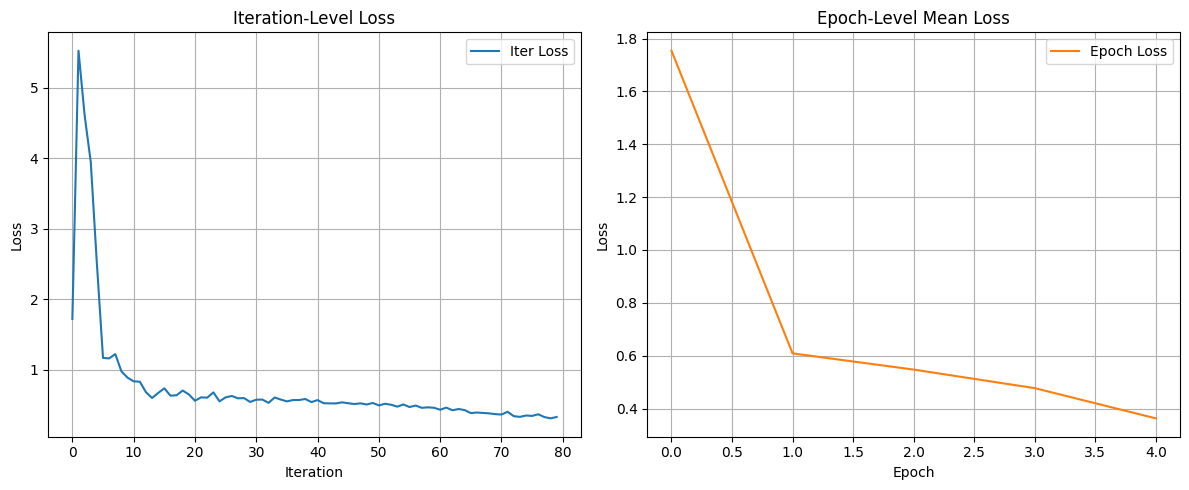

In [56]:
import matplotlib.pyplot as plt

# 创建画布和两个子图（1行2列）
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 可以根据需要调整 figsize

# 第一个子图：绘制每次迭代的 loss_list
axs[0].plot(loss_list, label="Iter Loss", color='tab:blue')
axs[0].set_xlabel("Iteration")
axs[0].set_ylabel("Loss")
axs[0].set_title("Iteration-Level Loss")
axs[0].legend()
axs[0].grid(True)

# 第二个子图：绘制每个 epoch 的 mean_loss
axs[1].plot(mean_loss, label="Epoch Loss", color='tab:orange')
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].set_title("Epoch-Level Mean Loss")
axs[1].legend()
axs[1].grid(True)

# 自动调整子图间距
plt.tight_layout()

# 保存图像
plt.savefig("train_loss_subplots.png")  # 可选

# 显示图像
plt.show()


## 评估

In [29]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, precision_recall_curve
from model.utils import Pooling
import argparse
import numpy as np

#### 全局变量定义

In [51]:
K = 10 # KNN训练样本数（训练样本必须小正常样本个数，测试集中必须同时包含正常样本和异常样本，推荐使用60-80%的数据做训练）
repeat_count = 5 # knn重复实验次数（-1表示只运行一次）
neighbor_ratio = 0.2 # 邻居数比例，KNN训练样本数*neighbor_ratio（K*neighbor_ratio必须大于0，否则KNN无法训练）

# 模型参数需要与训练时一致
optimizer_name = "ADAM"
weight_decay = 5e-4
lr = lr = 0.005

dataset_name = "wget"

device = "cpu"

pooling = "mean"

num_hidden = 256
max_epoch = 5
num_layers = 4
negative_slope = 0.2 # leaky relu的负斜率
mask_rate = 0.5 # 掩码率
alpha_l = 3 # sce损失函数的幂次，a>1越大对错误样本惩罚越厉害，越小对错误样本越容忍（鲁棒性更高）

batch_size = 1

#### 基于batch评估（标注的粒度为图）

In [46]:
def evaluate_batch_level_using_knn(repeat, dataset, embeddings, labels):
    """
    使用KNN算法评估批量级别的分类性能
    
    参数:
        repeat: 重复实验次数,-1表示只运行一次
        dataset: 数据集名称
        embeddings: 特征嵌入向量
        labels: 对应标签(0表示正常样本,1表示攻击样本)
    
    返回:
        AUC均值(和标准差)或单次AUC值
    """
    x, y = embeddings, labels
    train_count = K  # KNN训练样本数(仅使用正常样本)
    n_neighbors = min(int(train_count * neighbor_ratio), 10)  # 邻居数,不超过10
    
    # 分离正常样本和攻击样本的索引
    benign_idx = np.where(y == 0)[0]  # 正常样本索引
    attack_idx = np.where(y == 1)[0]  # 攻击样本索引
    
    if repeat != -1:  # 多次重复实验模式（重复repeat次）
        # 初始化各指标列表
        prec_list = []  # 精确率
        rec_list = []   # 召回率
        f1_list = []    # F1分数
        tp_list = []    # 真正例
        fp_list = []    # 假正例
        tn_list = []    # 真负例
        fn_list = []    # 假负例
        auc_list = []   # AUC值
        
        for s in range(repeat):
            set_random_seed(s)  # 设置随机种子保证可重复性
            # 打乱样本顺序
            np.random.shuffle(benign_idx)
            np.random.shuffle(attack_idx)
            
            # 构建训练集(仅使用正常样本)和测试集
            x_train = x[benign_idx[:train_count]]
            x_test = np.concatenate([x[benign_idx[train_count:]], x[attack_idx]], axis=0)
            y_test = np.concatenate([y[benign_idx[train_count:]], y[attack_idx]], axis=0)
            
            # 标准化特征
            x_train_mean = x_train.mean(axis=0)
            x_train_std = x_train.std(axis=0)
            x_train = (x_train - x_train_mean) / (x_train_std + 1e-6)  # 防止除零
            x_test = (x_test - x_train_mean) / (x_train_std + 1e-6)
            
            # 训练KNN模型
            nbrs = NearestNeighbors(n_neighbors=n_neighbors)
            nbrs.fit(x_train)
            # 对于x_train，计算每个样本的邻居距离
            # distances: [len(x_train), n_neighbors], 每个样本的邻居距离
            # indexes: [len(x_train), n_neighbors], 每个样本的邻居索引
            distances, indexes = nbrs.kneighbors(x_train, n_neighbors=n_neighbors)
            mean_distance = distances.mean() * n_neighbors / (n_neighbors - 1)
            distances, indexes = nbrs.kneighbors(x_test, n_neighbors=n_neighbors)

            # 计算异常分数，越大越异常
            score = distances.mean(axis=1) / mean_distance

            # 计算指标
            auc = roc_auc_score(y_test, score)
            prec, rec, threshold = precision_recall_curve(y_test, score)
            f1 = 2 * prec * rec / (rec + prec + 1e-9)
            max_f1_idx = np.argmax(f1)
            best_thres = threshold[max_f1_idx]
            prec_list.append(prec[max_f1_idx])
            rec_list.append(rec[max_f1_idx])
            f1_list.append(f1[max_f1_idx])

            tn = 0
            fn = 0
            tp = 0
            fp = 0
            for i in range(len(y_test)):
                if y_test[i] == 1.0 and score[i] >= best_thres:
                    tp += 1
                if y_test[i] == 1.0 and score[i] < best_thres:
                    fn += 1
                if y_test[i] == 0.0 and score[i] < best_thres:
                    tn += 1
                if y_test[i] == 0.0 and score[i] >= best_thres:
                    fp += 1
            
            # 记录本轮结果
            prec_list.append(prec[max_f1_idx])
            rec_list.append(rec[max_f1_idx])
            f1_list.append(f1[max_f1_idx])
            tp_list.append(tp)
            fp_list.append(fp)
            fn_list.append(fn)
            tn_list.append(tn)
            auc_list.append(auc)
        
        # 输出多次实验的统计结果
        print('AUC: {}+{}'.format(np.mean(auc_list), np.std(auc_list)))
        print('F1: {}+{}'.format(np.mean(f1_list), np.std(f1_list)))
        print('PRECISION: {}+{}'.format(np.mean(prec_list), np.std(prec_list)))
        print('RECALL: {}+{}'.format(np.mean(rec_list), np.std(rec_list)))
        print('TN: {}+{}'.format(np.mean(tn_list), np.std(tn_list)))
        print('FN: {}+{}'.format(np.mean(fn_list), np.std(fn_list)))
        print('TP: {}+{}'.format(np.mean(tp_list), np.std(tp_list)))
        print('FP: {}+{}'.format(np.mean(fp_list), np.std(fp_list)))
        return np.mean(auc_list), np.std(auc_list)
    
    else:  # 单次实验模式
        set_random_seed(0)
        np.random.shuffle(benign_idx)
        np.random.shuffle(attack_idx)
        
        # 构建训练测试集(同上)
        x_train = x[benign_idx[:train_count]]
        x_test = np.concatenate([x[benign_idx[train_count:]], x[attack_idx]], axis=0)
        y_test = np.concatenate([y[benign_idx[train_count:]], y[attack_idx]], axis=0)
        
        # 标准化特征
        x_train_mean = x_train.mean(axis=0)
        x_train_std = x_train.std(axis=0)
        x_train = (x_train - x_train_mean) / x_train_std
        x_test = (x_test - x_train_mean) / x_train_std
        
        # 训练KNN模型并计算异常分数(同上)
        nbrs = NearestNeighbors(n_neighbors=n_neighbors)
        nbrs.fit(x_train)
        distances, indexes = nbrs.kneighbors(x_train, n_neighbors=n_neighbors)
        mean_distance = distances.mean() * n_neighbors / (n_neighbors - 1)
        distances, indexes = nbrs.kneighbors(x_test, n_neighbors=n_neighbors)

        score = distances.mean(axis=1) / mean_distance
        
        # 计算评估指标
        auc = roc_auc_score(y_test, score)
        prec, rec, threshold = precision_recall_curve(y_test, score)
        f1 = 2 * prec * rec / (rec + prec + 1e-9)
        best_idx = np.argmax(f1)
        best_thres = threshold[best_idx]

        tn = 0
        fn = 0
        tp = 0
        fp = 0
        for i in range(len(y_test)):
            if y_test[i] == 1.0 and score[i] >= best_thres:
                tp += 1
            if y_test[i] == 1.0 and score[i] < best_thres:
                fn += 1
            if y_test[i] == 0.0 and score[i] < best_thres:
                tn += 1
            if y_test[i] == 0.0 and score[i] >= best_thres:
                fp += 1
        
        # 输出单次实验结果
        print('AUC: {}'.format(auc))
        print('F1: {}'.format(f1[best_idx]))
        print('PRECISION: {}'.format(prec[best_idx]))
        print('RECALL: {}'.format(rec[best_idx]))
        print('TN: {}'.format(tn))
        print('FN: {}'.format(fn))
        print('TP: {}'.format(tp))
        print('FP: {}'.format(fp))
        return auc, 0.0

In [ ]:
def batch_level_evaluation(model, pooler, device, method, dataset, n_dim=0, e_dim=0):
    model.eval() # 推理模式
    x_list = []
    y_list = []
    # KNN使用的数据集应该与模型训练使用的数据集区分开
    data = load_batch_level_dataset(dataset)
    full = data['full_index']
    graphs = data['dataset']
    with torch.no_grad():
        for i in full:
            g = transform_graph(graphs[i][0], n_dim, e_dim).to(device) # g是图特征向量
            label = graphs[i][1] # label是图的标签
            out = model.embed(g) # 获取潜在空间的特征
            if dataset != 'wget':
                out = pooler(g, out).cpu().numpy() # 将整张图池化为一个特征向量，作为特征摘要
            else:
                out = pooler(g, out, n_types=data['n_feat']).cpu().numpy()
            y_list.append(label)
            x_list.append(out)
    x = np.concatenate(x_list, axis=0)
    y = np.array(y_list)
    if 'knn' in method:
        test_auc, test_std = evaluate_batch_level_using_knn(repeat_count, dataset, x, y)
    else:
        raise NotImplementedError
    return test_auc, test_std

#### 基于实体的标注（标注的粒度为结点和边）

In [ ]:
def evaluate_entity_level_using_knn(dataset, x_train, x_test, y_test):
    x_train_mean = x_train.mean(axis=0)
    x_train_std = x_train.std(axis=0)
    x_train = (x_train - x_train_mean) / x_train_std
    x_test = (x_test - x_train_mean) / x_train_std

    if dataset == 'cadets':
        n_neighbors = 200
    else:
        n_neighbors = 10

    nbrs = NearestNeighbors(n_neighbors=n_neighbors, n_jobs=-1)
    nbrs.fit(x_train)

    save_dict_path = './eval_result/distance_save_{}.pkl'.format(dataset)
    if not os.path.exists(save_dict_path):
        idx = list(range(x_train.shape[0]))
        random.shuffle(idx)
        distances, _ = nbrs.kneighbors(x_train[idx][:min(50000, x_train.shape[0])], n_neighbors=n_neighbors)
        del x_train
        mean_distance = distances.mean()
        del distances
        distances, _ = nbrs.kneighbors(x_test, n_neighbors=n_neighbors)
        save_dict = [mean_distance, distances.mean(axis=1)]
        distances = distances.mean(axis=1)
        with open(save_dict_path, 'wb') as f:
            pkl.dump(save_dict, f)
    else:
        with open(save_dict_path, 'rb') as f:
            mean_distance, distances = pkl.load(f)
    score = distances / mean_distance
    del distances
    auc = roc_auc_score(y_test, score)
    prec, rec, threshold = precision_recall_curve(y_test, score)
    f1 = 2 * prec * rec / (rec + prec + 1e-9)
    best_idx = -1
    for i in range(len(f1)):
        # To repeat peak performance
        if dataset == 'trace' and rec[i] < 0.99979:
            best_idx = i - 1
            break
        if dataset == 'theia' and rec[i] < 0.99996:
            best_idx = i - 1
            break
        if dataset == 'cadets' and rec[i] < 0.9976:
            best_idx = i - 1
            break
    best_thres = threshold[best_idx]

    tn = 0
    fn = 0
    tp = 0
    fp = 0
    for i in range(len(y_test)):
        if y_test[i] == 1.0 and score[i] >= best_thres:
            tp += 1
        if y_test[i] == 1.0 and score[i] < best_thres:
            fn += 1
        if y_test[i] == 0.0 and score[i] < best_thres:
            tn += 1
        if y_test[i] == 0.0 and score[i] >= best_thres:
            fp += 1
    print('AUC: {}'.format(auc))
    print('F1: {}'.format(f1[best_idx]))
    print('PRECISION: {}'.format(prec[best_idx]))
    print('RECALL: {}'.format(rec[best_idx]))
    print('TN: {}'.format(tn))
    print('FN: {}'.format(fn))
    print('TP: {}'.format(tp))
    print('FP: {}'.format(fp))
    return auc, 0.0, None, None

In [ ]:
def evaluate_entity_level_using_knn(dataset, x_train, x_test, y_test):
    x_train_mean = x_train.mean(axis=0)
    x_train_std = x_train.std(axis=0)
    x_train = (x_train - x_train_mean) / x_train_std
    x_test = (x_test - x_train_mean) / x_train_std

    if dataset == 'cadets':
        n_neighbors = 200
    else:
        n_neighbors = 10

    nbrs = NearestNeighbors(n_neighbors=n_neighbors, n_jobs=-1)
    nbrs.fit(x_train)

    save_dict_path = './eval_result/distance_save_{}.pkl'.format(dataset)
    if not os.path.exists(save_dict_path):
        idx = list(range(x_train.shape[0]))
        random.shuffle(idx)
        distances, _ = nbrs.kneighbors(x_train[idx][:min(50000, x_train.shape[0])], n_neighbors=n_neighbors)
        del x_train
        mean_distance = distances.mean()
        del distances
        distances, _ = nbrs.kneighbors(x_test, n_neighbors=n_neighbors)
        save_dict = [mean_distance, distances.mean(axis=1)]
        distances = distances.mean(axis=1)
        with open(save_dict_path, 'wb') as f:
            pkl.dump(save_dict, f)
    else:
        with open(save_dict_path, 'rb') as f:
            mean_distance, distances = pkl.load(f)
    score = distances / mean_distance
    del distances
    auc = roc_auc_score(y_test, score)
    prec, rec, threshold = precision_recall_curve(y_test, score)
    f1 = 2 * prec * rec / (rec + prec + 1e-9)
    best_idx = -1
    for i in range(len(f1)):
        # To repeat peak performance
        if dataset == 'trace' and rec[i] < 0.99979:
            best_idx = i - 1
            break
        if dataset == 'theia' and rec[i] < 0.99996:
            best_idx = i - 1
            break
        if dataset == 'cadets' and rec[i] < 0.9976:
            best_idx = i - 1
            break
    best_thres = threshold[best_idx]

    tn = 0
    fn = 0
    tp = 0
    fp = 0
    for i in range(len(y_test)):
        if y_test[i] == 1.0 and score[i] >= best_thres:
            tp += 1
        if y_test[i] == 1.0 and score[i] < best_thres:
            fn += 1
        if y_test[i] == 0.0 and score[i] < best_thres:
            tn += 1
        if y_test[i] == 0.0 and score[i] >= best_thres:
            fp += 1
    print('AUC: {}'.format(auc))
    print('F1: {}'.format(f1[best_idx]))
    print('PRECISION: {}'.format(prec[best_idx]))
    print('RECALL: {}'.format(rec[best_idx]))
    print('TN: {}'.format(tn))
    print('FN: {}'.format(fn))
    print('TP: {}'.format(tp))
    print('FP: {}'.format(fp))
    return auc, 0.0, None, None

#### 执行评估

构建参数

In [49]:
# 加载数据，提取结点和边的特征维数
dataset = load_batch_level_dataset(dataset_name)
n_dim = dataset["n_feat"]
e_dim = dataset["e_feat"]

model_args = argparse.Namespace(
    num_hidden=num_hidden,
    num_layers=num_layers,
    negative_slope=negative_slope,
    mask_rate=mask_rate,
    alpha_l=alpha_l,
    n_dim=n_dim,
    e_dim=e_dim,
    pooling=pooling,
    dataset=dataset_name,
)

Loading processed wget dataset...


[n_graph, n_node_feat, n_edge_feat]: [20, 8, 4]


In [52]:
# device = torch.device(device)

set_random_seed(0)

model = build_model(model_args)
# 加载模型参数
model.load_state_dict(torch.load("./checkpoints/checkpoint-{}.pt".format(dataset_name), map_location=device))
model = model.to(device)
pooler = Pooling(model_args.pooling)
test_auc, test_std = batch_level_evaluation(model, pooler, device, ['knn'], model_args.dataset, model_args.n_dim,
                                            model_args.e_dim)
print(f"#Test_AUC: {test_auc:.4f}±{test_std:.4f}")

d:\Desktop\UniAPT\scripts\model\my_model.py:38: UserWarning: nn.init.xavier_uniform is now deprecated in favor of nn.init.xavier_uniform_.
  nn.init.xavier_uniform(m.weight)


Loading processed wget dataset...
[n_graph, n_node_feat, n_edge_feat]: [20, 8, 4]
AUC: 0.6583333333333333+0.19790570145063197
F1: 0.7211721607152171+0.09147082706690582
PRECISION: 0.6222222222222221+0.2030629653610785
RECALL: 0.95+0.09999999999999999
TN: 3.0+1.7888543819998317
FN: 0.2+0.4000000000000001
TP: 3.8+0.39999999999999997
FP: 3.0+1.7888543819998317
#Test_AUC: 0.6583±0.1979
